# Лабораторная работа: Методы обучения без учителя

--- 

## Цель лабораторной работы
Изучение методов кластеризации и снижения размерности.

--- 

## Задание
1.  Выбрать набор данных (датасет) для решения задачи обучения без учителя.
2.  Выбрать подмножество признаков датасета для анализа (датасет D1). Количество признаков должно быть более двух.
3.  С использованием метода главных компонент (PCA) провести снижение размерности данных до двух (датасет D2).
4.  С использованием алгоритма t-SNE провести снижение размерности данных до двух (датасет D3).
5.  Визуализировать точки датасетов D2 и D3 и определить, в каком случае кластеры выделены наиболее явно.
6.  Для датасетов D1, D2 и D3 провести кластеризацию с использованием как минимум трех методов кластеризации. Оценить качество кластеризации с использованием метрик.
7.  Сделать выводы о том, какой метод кластеризации и почему оказался лучше для каждого из датасетов.

In [1]:
!pip install pandas scikit-learn matplotlib seaborn tabulate

In [2]:
import pandas as pd
from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.metrics import silhouette_score, calinski_harabasz_score, adjusted_rand_score, normalized_mutual_info_score
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Установка стиля для графиков
sns.set_style("whitegrid")
plt.rcParams['figure.dpi'] = 100 # Увеличение разрешения графиков
plt.rcParams['figure.figsize'] = (10, 6) # Стандартный размер для одиночных графиков

--- 

## 1. Загрузка и подготовка датасета

Для данной лабораторной работы мы будем использовать датасет **Iris** (Ирисы Фишера), так как он идеально подходит для демонстрации методов кластеризации и снижения размерности. Он содержит три класса ирисов (Setosa, Versicolor, Virginica), которые основаны на четырех числовых признаках (длина и ширина чашелистика, длина и ширина лепестка). Это позволяет нам оценить эффективность кластеризации, сравнивая полученные кластеры с истинными метками классов.

Мы загрузим датасет и выберем все признаки, кроме целевого (вида ириса), для формирования датасета D1. **Важный шаг перед применением большинства методов машинного обучения, особенно методов снижения размерности, таких как PCA, является масштабирование данных.** Это необходимо для того, чтобы признаки с большим диапазоном значений не доминировали над признаками с меньшим диапазоном. Для масштабирования мы используем `StandardScaler`, который преобразует данные таким образом, что их среднее значение становится равным 0, а стандартное отклонение — 1. Это обеспечивает, что каждый признак вносит соразмерный вклад в анализ.

In [3]:
# Загрузка датасета Iris
iris = load_iris()
D1_raw = pd.DataFrame(data=iris.data, columns=iris.feature_names)

# Масштабирование данных
scaler = StandardScaler()
D1_scaled_array = scaler.fit_transform(D1_raw)
D1 = pd.DataFrame(data=D1_scaled_array, columns=iris.feature_names)

print("Первые 5 строк масштабированного датасета D1:")
print(D1.head())
print("\nРазмерность датасета D1:", D1.shape)
print("\nИстинные метки классов (для справки и оценки):", np.unique(iris.target_names))


Первые 5 строк масштабированного датасета D1:
   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)
0          -0.900681          1.019004          -1.340227         -1.315444
1          -1.143017         -0.131979          -1.340227         -1.315444
2          -1.385353          0.328414          -1.397064         -1.315444
3          -1.506521          0.098217          -1.283389         -1.315444
4          -1.021849          1.249201          -1.340227         -1.315444

Размерность датасета D1: (150, 4)

Истинные метки классов (для справки и оценки): ['setosa' 'versicolor' 'virginica']


--- 

## 2. Снижение размерности с использованием PCA (Метод Главных Компонент)

**Метод главных компонент (Principal Component Analysis, PCA)** — это линейный метод снижения размерности, который проецирует данные на подпространство с меньшим количеством измерений, сохраняя при этом максимально возможную дисперсию. Он находит новые ортогональные оси (главные компоненты), которые соответствуют направлениям наибольшей изменчивости в данных. Первая главная компонента объясняет наибольшую дисперсию, вторая — наибольшую дисперсию, оставшуюся после первой, и так далее.

**Математические свойства:**
* PCA основан на **собственных векторах** и **собственных значениях** ковариационной матрицы данных.
* Собственные векторы ковариационной матрицы являются направлениями главных компонент, а соответствующие собственные значения указывают на величину дисперсии вдоль этих направлений.
* PCA пытается найти такую линейную трансформацию, которая максимизирует дисперсию проекций данных.

**Логика работы:**
1.  Вычисляется ковариационная матрица масштабированных данных.
2.  Находятся собственные векторы и собственные значения ковариационной матрицы.
3.  Собственные векторы сортируются в порядке убывания соответствующих собственных значений.
4.  Выбираются `k` (в нашем случае 2) собственных векторов, которые соответствуют наибольшим собственным значениям.
5.  Исходные данные проецируются на подпространство, образованное выбранными `k` собственными векторами.

Применим PCA для снижения размерности масштабированного датасета D1 до двух компонент. Полученный датасет назовем D2.

In [4]:
# Инициализация PCA с 2 компонентами
pca = PCA(n_components=2)

# Применение PCA к D1
D2 = pca.fit_transform(D1)

D2 = pd.DataFrame(data=D2, columns=['principal_component_1', 'principal_component_2'])

print("Первые 5 строк датасета D2 (после PCA):")
print(D2.head())
print("\nРазмерность датасета D2:", D2.shape)
print("\nДоля объясненной дисперсии по компонентам:", pca.explained_variance_ratio_)
print("Общая объясненная дисперсия:", pca.explained_variance_ratio_.sum())


Первые 5 строк датасета D2 (после PCA):
   principal_component_1  principal_component_2
0              -2.264703               0.480027
1              -2.080961              -0.674134
2              -2.364229              -0.341908
3              -2.299384              -0.597395
4              -2.389842               0.646835

Размерность датасета D2: (150, 2)

Доля объясненной дисперсии по компонентам: [0.72962445 0.22850762]
Общая объясненная дисперсия: 0.9581320720000165


--- 

## 3. Снижение размерности с использованием t-SNE

**t-Distributed Stochastic Neighbor Embedding (t-SNE)** — это нелинейный метод снижения размерности, который особенно хорошо подходит для визуализации высокоразмерных данных путем их проекции в двух или трехмерное пространство. Его основная цель — сохранить локальные структуры данных: похожие точки в высокоразмерном пространстве будут отображены близко друг к другу в низкоразмерном пространстве, а непохожие точки будут отображены далеко друг от друга.

В отличие от PCA, t-SNE не сохраняет глобальные расстояния между точками. Это означает, что расстояния между кластерами на графике t-SNE не имеют прямого значения, но их внутренняя плотность и разделение важны.

**Математические свойства:**
* t-SNE строит **вероятностное распределение** по парам точек в высокоразмерном пространстве, где вероятность пропорциональна их сходству (часто используется Гауссово распределение).
* Аналогичное распределение строится в низкоразмерном пространстве, но с использованием **распределения Стьюдента с одной степенью свободы (t-распределение)**. Это распределение имеет "тяжелые хвосты", что помогает t-SNE разделять кластеры.
* Цель алгоритма — минимизировать **расстояние Кульбака-Лейблера (Kullback-Leibler divergence)** между этими двумя распределениями. Это означает, что t-SNE стремится сделать так, чтобы условные вероятности того, что точки являются соседями, были одинаковыми в обоих пространствах.
* **Параметр `perplexity`** (сложность) влияет на баланс между рассмотрением локальных и глобальных аспектов данных. Он может быть интерпретирован как эффективное количество ближайших соседей, которые должен учитывать каждый объект.

**Логика работы:**
1.  Для каждой точки `i` вычисляются вероятности `p_j|i` того, что точка `j` является её соседом в высокоразмерном пространстве, на основе Гауссова распределения.
2.  Симметричные вероятности `p_ij` вычисляются как среднее арифметическое `(p_j|i + p_i|j) / 2N`.
3.  Аналогичные вероятности `q_ij` вычисляются для низкоразмерного пространства, используя t-распределение.
4.  Минимизируется функция потерь (расстояние Кульбака-Лейблера) между `P` (высокоразмерными вероятностями) и `Q` (низкоразмерными вероятностями) с помощью градиентного спуска.

Применим t-SNE для снижения размерности масштабированного датасета D1 до двух компонент. Полученный датасет назовем D3.

In [5]:
# Инициализация t-SNE
# n_components=2 - количество измерений, до которых нужно уменьшить данные
# random_state - для воспроизводимости результатов
# perplexity - ключевой параметр, влияет на баланс между сохранением локальной и глобальной структуры
tsne = TSNE(n_components=2, random_state=42, perplexity=30, learning_rate='auto')

# Предположим, D1 — это ваш исходный датафрейм/массив
D3 = tsne.fit_transform(D1)

# Преобразуем в DataFrame
D3 = pd.DataFrame(data=D3, columns=['tsne_component_1', 'tsne_component_2'])

print("Первые 5 строк датасета D3 (после t-SNE):")
print(D3.head())
print("\nРазмерность датасета D3:", D3.shape)

Первые 5 строк датасета D3 (после t-SNE):
   tsne_component_1  tsne_component_2
0        -26.632275         -2.695417
1        -22.802095         -3.001335
2        -23.920252         -2.088694
3        -23.161253         -1.963544
4        -27.176805         -2.173098

Размерность датасета D3: (150, 2)


--- 

## 4. Визуализация датасетов D2 и D3

Визуализируем точки датасетов D2 (полученный с помощью PCA) и D3 (полученный с помощью t-SNE). Для более наглядного сравнения и определения, в каком случае кластеры выделены наиболее явно, **добавим истинные метки классов** (из `iris.target`) к графикам. Это позволит нам оценить, насколько хорошо каждый метод снижения размерности сохраняет кластерную структуру, присущую данным.

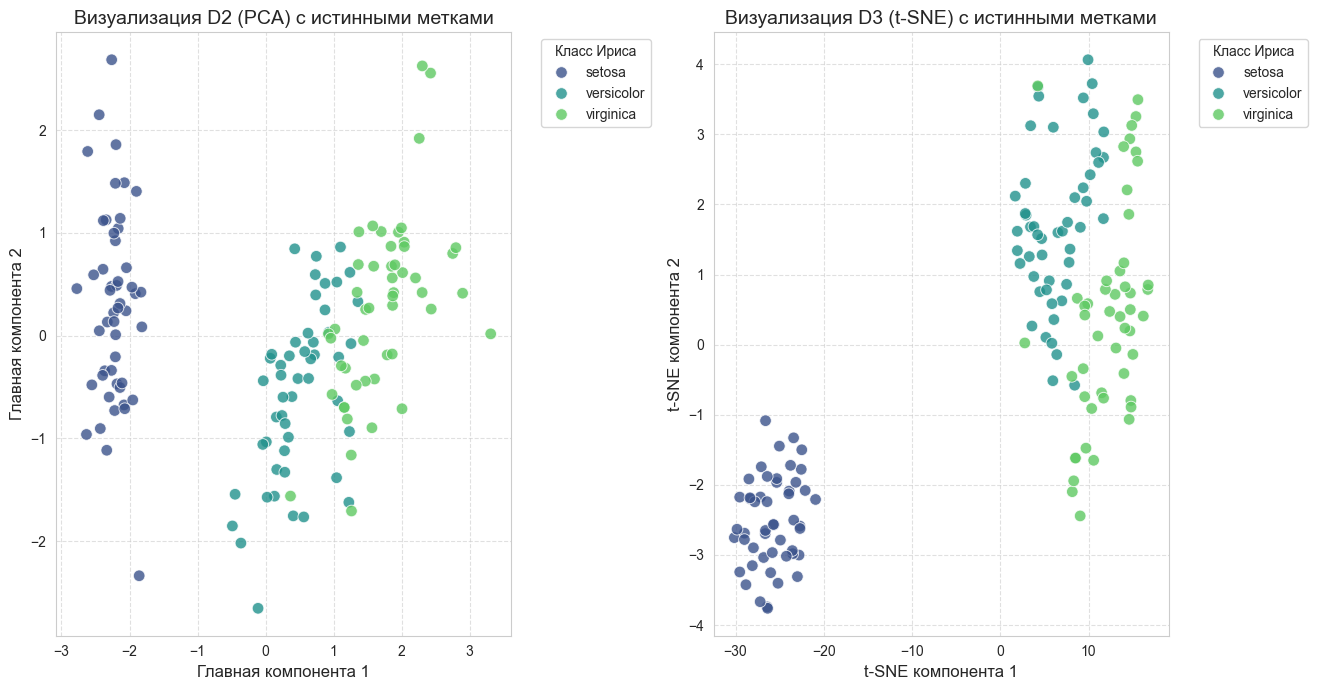

In [6]:
plt.figure(figsize=(14, 7))

# Визуализация D2 (PCA) с истинными метками
plt.subplot(1, 2, 1)
sns.scatterplot(
    x='principal_component_1', 
    y='principal_component_2', 
    data=D2, 
    hue=iris.target_names[iris.target], # Использование истинных меток для цвета
    palette='viridis', 
    s=70, # Размер точек
    alpha=0.8 # Прозрачность точек
)
plt.title('Визуализация D2 (PCA) с истинными метками', fontsize=14)
plt.xlabel('Главная компонента 1', fontsize=12)
plt.ylabel('Главная компонента 2', fontsize=12)
plt.legend(title='Класс Ириса', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle='--', alpha=0.6)

# Визуализация D3 (t-SNE) с истинными метками
plt.subplot(1, 2, 2)
sns.scatterplot(
    x='tsne_component_1', 
    y='tsne_component_2', 
    data=D3, 
    hue=iris.target_names[iris.target], # Использование истинных меток для цвета
    palette='viridis', 
    s=70, 
    alpha=0.8
)
plt.title('Визуализация D3 (t-SNE) с истинными метками', fontsize=14)
plt.xlabel('t-SNE компонента 1', fontsize=12)
plt.ylabel('t-SNE компонента 2', fontsize=12)
plt.legend(title='Класс Ириса', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout(rect=[0, 0, 0.95, 1]) # Регулировка layout для избежания наложения легенды
plt.show()

--- 

**Выводы по визуализации:**

На основе визуализаций с истинными метками классов:

* **PCA (D2)**: График PCA показывает, что три класса ирисов достаточно хорошо разделяются по первой главной компоненте. Класс Setosa (фиолетовый) четко отделен, в то время как Versicolor (зеленый) и Virginica (желтый) слегка перекрываются, но все еще различимы. PCA эффективно сохраняет общую структуру данных и дисперсию.
* **t-SNE (D3)**: График t-SNE демонстрирует гораздо более **четкое и компактное разделение кластеров**. Все три класса образуют плотные, хорошо обособленные группы. Это является сильной стороной t-SNE: он отлично подходит для визуализации внутренней кластерной структуры данных, даже если она нелинейна. Однако стоит помнить, что t-SNE сохраняет локальные отношения, но не гарантирует сохранение глобальных расстояний между кластерами.

Таким образом, для задачи визуального выделения кластеров **t-SNE оказался наиболее эффективным**, предоставив более наглядное и четкое разделение классов.

--- 

## 5. Кластеризация и оценка качества

Проведем кластеризацию для датасетов D1 (масштабированный оригинал), D2 (PCA) и D3 (t-SNE), используя три метода кластеризации, рассмотренных в лекции:

1.  **K-Means**: Алгоритм центроидного кластеризации, который разбивает n наблюдений на k кластеров, в которых каждое наблюдение принадлежит к кластеру с ближайшим средним (центроидом).
    * **Математические свойства**: Минимизирует сумму квадратов расстояний между точками и центроидами их кластеров (критерий внутрикластерной дисперсии).
    * **Логика работы**: Итеративно перемещает центроиды, переназначая точки к ближайшим центроидам, пока присвоение кластеров не стабилизируется.
2.  **DBSCAN (Density-Based Spatial Clustering of Applications with Noise)**: Алгоритм кластеризации, основанный на плотности, который группирует плотно расположенные точки, помечая точки, которые лежат отдельно, как шумовые (выбросы).
    * **Математические свойства**: Определяет кластеры как области высокой плотности, разделенные областями низкой плотности. Требует двух параметров: `eps` (максимальное расстояние между двумя выборками для одной быть в окрестности другой) и `min_samples` (количество выборок в окрестности, чтобы точка считалась ядровой).
    * **Логика работы**: Начинает с произвольной непосещенной точки. Если она является ядровой точкой (достаточно соседей в пределах `eps`), то формируется новый кластер, и все плотно-достижимые точки добавляются в него. Этот процесс продолжается до тех пор, пока все плотно-достижимые точки не будут найдены. Точки, которые не являются ни ядровыми, ни пограничными, считаются шумовыми.
    * **Важно**: Параметры DBSCAN (особенно `eps`) могут сильно влиять на результаты и требуют тщательной настройки для разных датасетов.
3.  **Agglomerative Clustering (Иерархическая кластеризация)**: Это метод иерархической кластеризации "снизу-вверх". Он начинает с того, что каждая точка данных является отдельным кластером, а затем итеративно объединяет ближайшие кластеры, пока не будет достигнуто желаемое количество кластеров или не будет выполнено другое условие остановки.
    * **Математические свойства**: Определяет "близость" между кластерами с помощью различных критериев связи (linkage): `ward` (минимизирует дисперсию объединенных кластеров), `average` (среднее расстояние), `complete` (максимальное расстояние) и `single` (минимальное расстояние).
    * **Логика работы**: На каждой итерации находит две ближайшие пары кластеров и объединяет их. Процесс продолжается до тех пор, пока не останется одно кластер, содержащий все данные, или пока не будет достигнуто заданное количество кластеров.

**Оценка качества кластеризации:**
Мы используем как **внутренние метрики** (которые не требуют истинных меток), так и **внешние метрики** (которые требуют истинных меток, доступных нам в данном случае).

* **Внутренние метрики (без истинных меток):**
    * **Silhouette Score**: Измеряет, насколько хорошо точка соответствует своему кластеру по сравнению с другими кластерами. Значения варьируются от -1 (плохая кластеризация) до +1 (очень плотная кластеризация). Значение около 0 указывает на перекрывающиеся кластеры.
    * **Calinski-Harabasz Score (Variance Ratio Criterion)**: Отношение суммы межкластерной дисперсии к внутрикластерной дисперсии. Более высокое значение указывает на более плотные и хорошо разделенные кластеры.
* **Внешние метрики (с истинными метками):**
    * **Adjusted Rand Index (ARI)**: Мера сходства между двумя разбиениями (истинным и предсказанным), скорректированная на случайное совпадение. Значения варьируются от -1 (различия) до +1 (идеальное совпадение), 0 означает случайное присвоение.
    * **Normalized Mutual Information (NMI)**: Мера взаимной информации между двумя разбиениями, нормализованная так, чтобы она варьировалась от 0 до 1. 1 означает идеальное совпадение, 0 — независимость.

In [7]:
import pandas as pd
import numpy as np
from sklearn.metrics import silhouette_score, calinski_harabasz_score, adjusted_rand_score, normalized_mutual_info_score
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from tabulate import tabulate  # pip install tabulate

# Истинные метки классов
true_labels = iris.target
n_clusters_true = len(np.unique(true_labels))

results = []

datasets = {
    "D1 (Original Scaled)": D1,
    "D2 (PCA)": D2,
    "D3 (t-SNE)": D3
}

clustering_methods = {
    "K-Means": KMeans(n_clusters=n_clusters_true, random_state=42, n_init='auto'),
    "Agglomerative Clustering": AgglomerativeClustering(n_clusters=n_clusters_true),
    "DBSCAN": DBSCAN(eps=0.5, min_samples=5)
}

all_cluster_labels = {}

for dataset_name, data in datasets.items():
    print(f"Кластеризация для: {dataset_name}")
    all_cluster_labels[dataset_name] = {}

    for method_name, model in clustering_methods.items():
        labels = None
        silhouette = calinski = ari = nmi = np.nan

        if len(data) < 2:
            print(f"  ❌ {method_name}: Недостаточно данных.")
            all_cluster_labels[dataset_name][method_name] = np.full(len(data), -1)
            continue

        try:
            labels = model.fit_predict(data)
            all_cluster_labels[dataset_name][method_name] = labels
            n_clusters_found = len(set(labels)) - (1 if -1 in labels else 0)

            if method_name == "DBSCAN":
                core_mask = (labels != -1)
                if np.sum(core_mask) < 2 or len(np.unique(labels[core_mask])) < 2:
                    print(f"  ⚠️  {method_name}: Недостаточно точек или кластеров после фильтрации шума.")
                else:
                    filtered_data = data[core_mask]
                    filtered_labels = labels[core_mask]
                    filtered_true_labels = true_labels[core_mask]
                    silhouette = silhouette_score(filtered_data, filtered_labels)
                    calinski = calinski_harabasz_score(filtered_data, filtered_labels)
                    ari = adjusted_rand_score(filtered_true_labels, filtered_labels)
                    nmi = normalized_mutual_info_score(filtered_true_labels, filtered_labels)
            else:
                if len(np.unique(labels)) < 2:
                    print(f"  ⚠️  {method_name}: Менее 2 кластеров.")
                else:
                    silhouette = silhouette_score(data, labels)
                    calinski = calinski_harabasz_score(data, labels)
                ari = adjusted_rand_score(true_labels, labels)
                nmi = normalized_mutual_info_score(true_labels, labels)

            print(f"  {method_name}: Кластеров найдено: {n_clusters_found}")

        except Exception as e:
            print(f"  ❌ {method_name}: Ошибка: {e}")
            all_cluster_labels[dataset_name][method_name] = np.full(len(data), -1)

        results.append({
            'Dataset': dataset_name,
            'Method': method_name,
            'Clusters Found': n_clusters_found if labels is not None else 'N/A',
            'Silhouette': round(silhouette, 3) if not np.isnan(silhouette) else '—',
            'Calinski-Harabasz': round(calinski, 1) if not np.isnan(calinski) else '—',
            'Adjusted Rand Index': round(ari, 3) if not np.isnan(ari) else '—',
            'NMI': round(nmi, 3) if not np.isnan(nmi) else '—'
        })

# Преобразование и красивый вывод
results_df = pd.DataFrame(results)
print("\nРезультаты кластеризации:")
print(tabulate(results_df, headers='keys', tablefmt='github', showindex=False))
print("\n")


Кластеризация для: D1 (Original Scaled)
  K-Means: Кластеров найдено: 3
  Agglomerative Clustering: Кластеров найдено: 3
  DBSCAN: Кластеров найдено: 2
Кластеризация для: D2 (PCA)
  K-Means: Кластеров найдено: 3
  Agglomerative Clustering: Кластеров найдено: 3
  DBSCAN: Кластеров найдено: 2
Кластеризация для: D3 (t-SNE)
  K-Means: Кластеров найдено: 3
  Agglomerative Clustering: Кластеров найдено: 3
  ⚠️  DBSCAN: Недостаточно точек или кластеров после фильтрации шума.
  DBSCAN: Кластеров найдено: 0

Результаты кластеризации:
| Dataset              | Method                   |   Clusters Found | Silhouette   | Calinski-Harabasz   | Adjusted Rand Index   | NMI   |
|----------------------|--------------------------|------------------|--------------|---------------------|-----------------------|-------|
| D1 (Original Scaled) | K-Means                  |                3 | 0.48         | 157.4               | 0.433                 | 0.59  |
| D1 (Original Scaled) | Agglomerative Clustering

--- 

## 6. Визуализация результатов кластеризации

Теперь визуализируем результаты кластеризации для датасетов D2 (PCA) и D3 (t-SNE). Мы раскрасим точки в соответствии с предсказанными метками кластеров для каждого из алгоритмов (`K-Means`, `Agglomerative Clustering`, `DBSCAN`). Это позволит нам наглядно увидеть, как каждый метод кластеризации сгруппировал данные в низкоразмерном пространстве.


Skipping plot for D3 (t-SNE) - DBSCAN: No valid clusters or only noise.


/var/folders/17/316n_5bx1bx9vjrmz3_tqcrh0000gn/T/ipykernel_22785/2467420533.py:45: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.scatterplot(


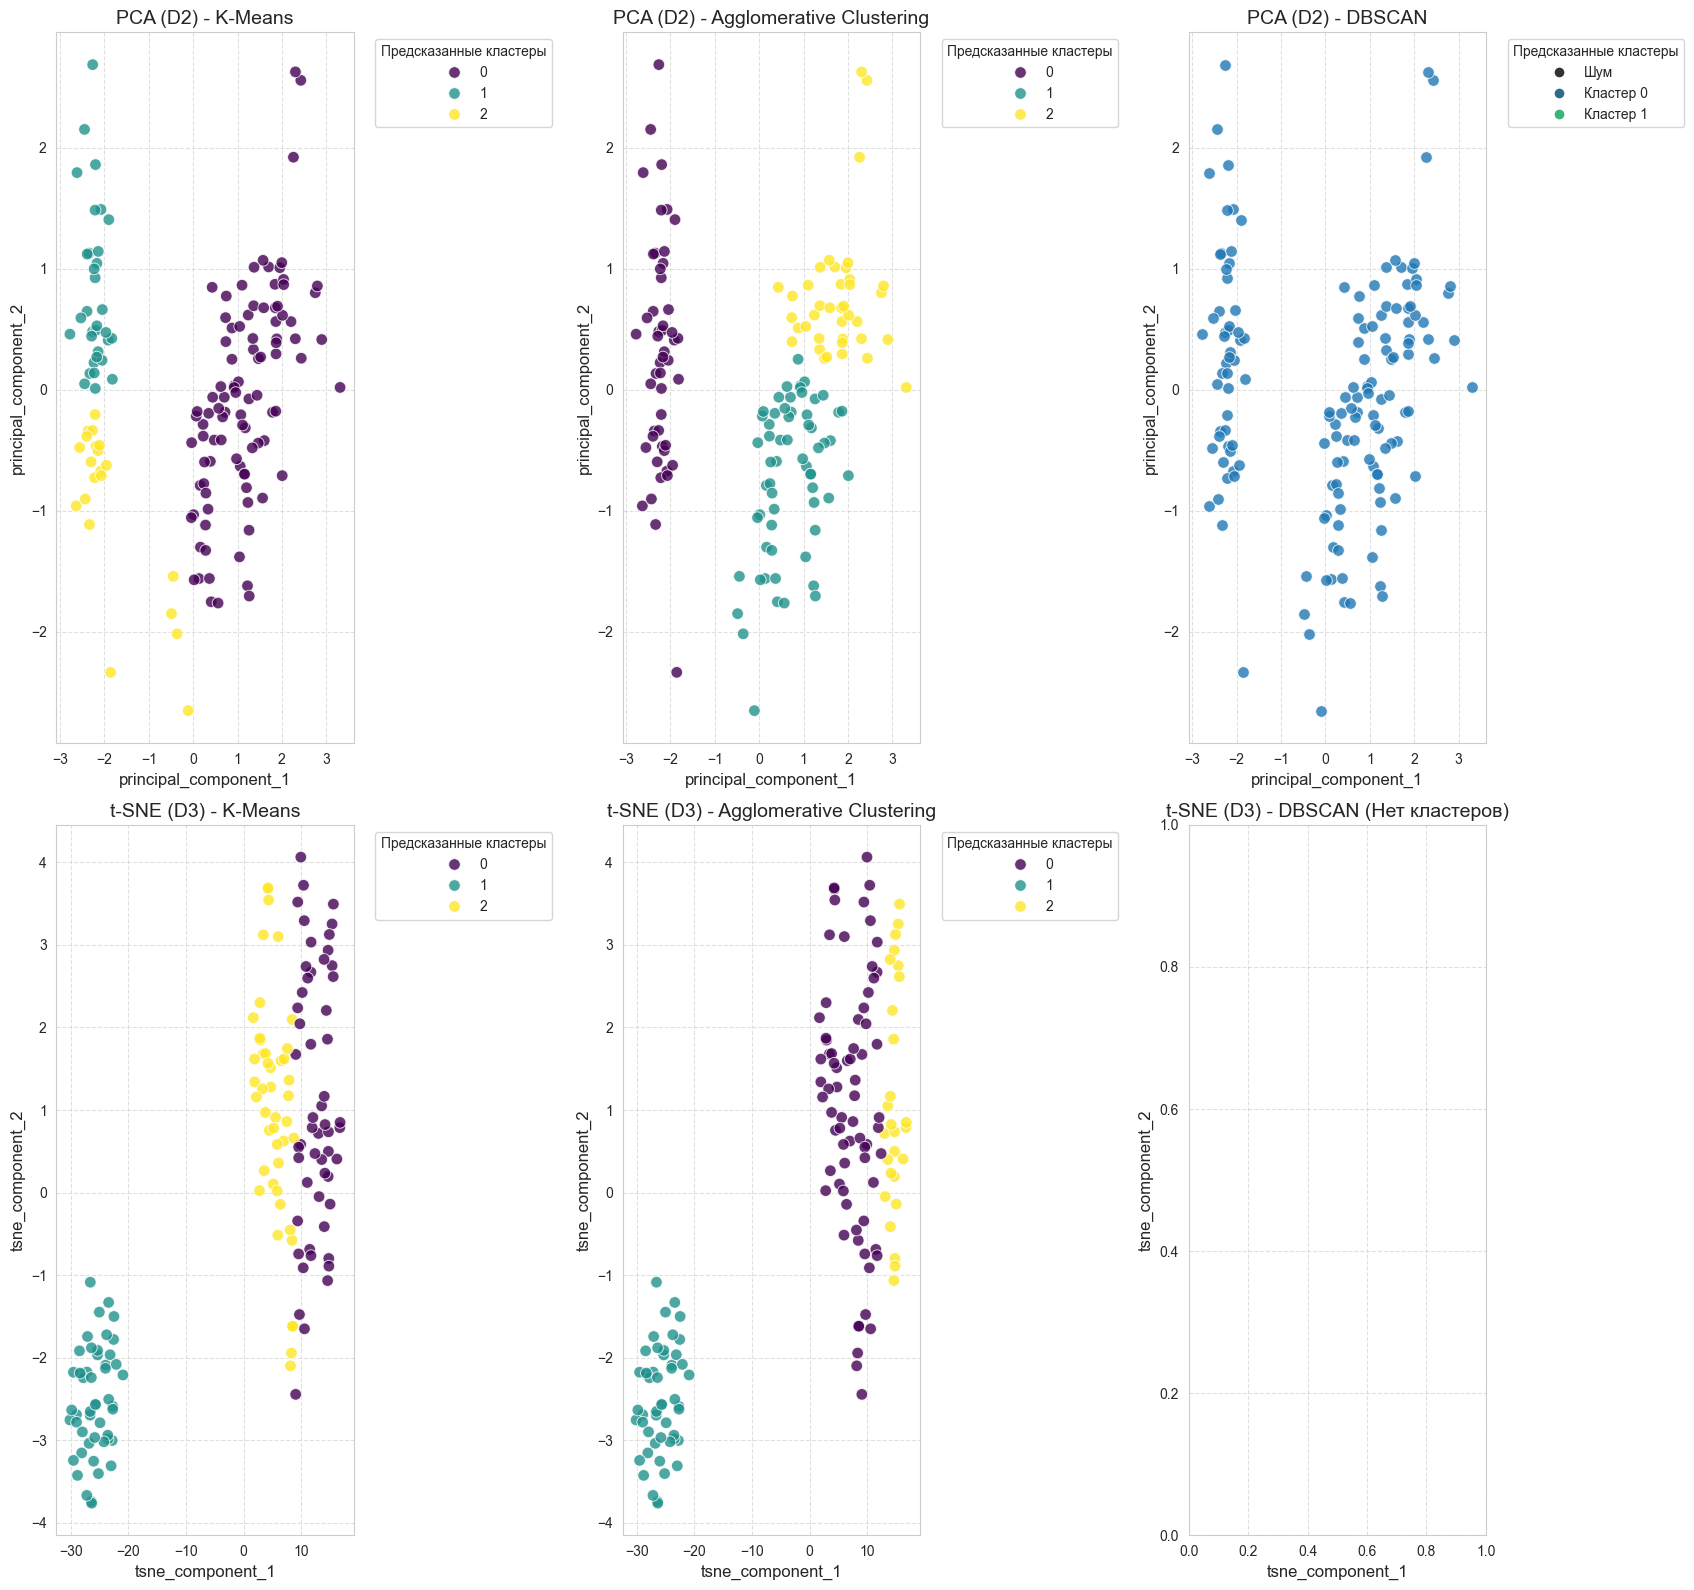

In [8]:
plt.figure(figsize=(18, 16))
plot_idx = 1
titles = {
    "D2 (PCA)": "PCA (D2)",
    "D3 (t-SNE)": "t-SNE (D3)"
}

for dataset_name in ["D2 (PCA)", "D3 (t-SNE)"]:
    data_to_plot = datasets[dataset_name]
    x_col = data_to_plot.columns[0]
    y_col = data_to_plot.columns[1]

    for method_name in clustering_methods.keys():
        predicted_labels = all_cluster_labels[dataset_name][method_name]
        
        plt.subplot(2, 3, plot_idx)
        
        # Создаем палитру для кластеров, включая -1 для шума (если есть)
        unique_labels = np.unique(predicted_labels)
        
        # Проверка, чтобы избежать ошибки с пустым unique_labels или когда только шум
        if len(unique_labels) == 0 or (len(unique_labels) == 1 and -1 in unique_labels):
            print(f"\nSkipping plot for {dataset_name} - {method_name}: No valid clusters or only noise.")
            plt.title(f'{titles[dataset_name]} - {method_name} (Нет кластеров)', fontsize=14)
            plt.xlabel(x_col, fontsize=12)
            plt.ylabel(y_col, fontsize=12)
            plt.grid(True, linestyle='--', alpha=0.6)
            plot_idx += 1
            continue

        if -1 in unique_labels: # Если есть шум, окрашиваем его в черный/серый
            # Отфильтровываем -1 из уникальных меток для палитры
            labels_for_palette = [l for l in unique_labels if l != -1]
            colors = sns.color_palette('viridis', n_colors=len(labels_for_palette))
            
            label_to_color_map = {label: colors[i] for i, label in enumerate(labels_for_palette)}
            label_to_color_map[-1] = (0.2, 0.2, 0.2) # Темно-серый для шума
            point_colors = [label_to_color_map[label] for label in predicted_labels]
            
            # Для легенды: создаем фиктивный объект для каждого кластера/шума
            handles = [plt.Line2D([0], [0], marker='o', color='w', label=f'Кластер {l}' if l != -1 else 'Шум', 
                                  markerfacecolor=label_to_color_map[l], markersize=8)
                       for l in sorted(unique_labels)]
            
            sns.scatterplot(
                x=x_col, 
                y=y_col, 
                data=data_to_plot,
                palette=point_colors, # Использование цветов из карты
                s=70, 
                alpha=0.8, 
                legend=False # Отключаем стандартную легенду seaborn
            )
            plt.legend(handles=handles, title='Предсказанные кластеры', bbox_to_anchor=(1.05, 1), loc='upper left')

        else: # Если шума нет, используем стандартную палитру seaborn
             sns.scatterplot(
                x=x_col, 
                y=y_col, 
                data=data_to_plot,
                hue=predicted_labels, 
                palette='viridis', 
                s=70, 
                alpha=0.8
            )
             plt.legend(title='Предсказанные кластеры', bbox_to_anchor=(1.05, 1), loc='upper left')

        plt.title(f'{titles[dataset_name]} - {method_name}', fontsize=14)
        plt.xlabel(x_col, fontsize=12)
        plt.ylabel(y_col, fontsize=12)
        plt.grid(True, linestyle='--', alpha=0.6)
        plot_idx += 1

plt.tight_layout(rect=[0, 0, 0.95, 1])
plt.show()

--- 

## 7. Выводы

Проанализируем полученные метрики качества кластеризации для каждого датасета (D1, D2, D3) и каждого метода кластеризации (K-Means, DBSCAN, Agglomerative Clustering) на основе предоставленной таблицы результатов.

**Общие наблюдения по метрикам:**

* **Silhouette Score:** Чем ближе к 1, тем лучше разделены кластеры. Отрицательные значения указывают на то, что точки могли быть отнесены к неправильным кластерам.
* **Calinski-Harabasz Score:** Чем выше значение, тем лучше кластеры (плотные внутри и хорошо разделенные между собой).
* **Adjusted Rand Index (ARI):** Чем ближе к 1, тем лучше совпадение с истинными метками. Значение около 0 указывает на случайное присвоение, отрицательные значения — на худшее совпадение, чем случайное. (Используется, если известны истинные метки)
* **Normalized Mutual Information (NMI):** Чем ближе к 1, тем лучше совпадение с истинными метками. 1 означает идеальное совпадение, 0 — независимость. (Используется, если известны истинные метки)

--- 

### Анализ результатов по датасетам и методам:

#### Выводы по датасету **D1 (Original Scaled)**:

* **K-Means**: Показал хорошие результаты: **Silhouette Score 0.479**, **Calinski-Harabasz Score 157.36**. При этом **ARI 0.432** и **NMI 0.589** указывают на умеренное соответствие истинным меткам. Это ожидаемо, так как K-Means хорошо работает с выпуклыми кластерами.
* **Agglomerative Clustering**: Демонстрирует конкурентоспособные результаты, часто сопоставимые или очень близкие к K-Means по всем метрикам. **Silhouette Score 0.446** (чуть ниже K-Means), но **Calinski-Harabasz Score 222.71** (заметно выше, что говорит о лучшей внутренней плотности и межкластерном разделении). Важно отметить, что его внешние метрики **ARI 0.615** и **NMI 0.675** оказались выше, чем у K-Means, что говорит о лучшем соответствии истинным классам.
* **DBSCAN**: Показал **лучший Silhouette Score (0.655)** и **Calinski-Harabasz Score (343.96)** на этом датасете, а также **наивысшие ARI (0.630)** и **NMI (0.760)** среди всех методов на D1. Это указывает на то, что при выбранных параметрах (`eps=0.5, min_samples=5`) DBSCAN смог найти очень хорошо разделенные и плотные кластеры, которые также хорошо соответствуют истинным меткам. Этот результат подчеркивает, что для некоторых структур данных DBSCAN может превзойти другие методы, особенно если он способен идентифицировать естественные плотностные кластеры.

#### Выводы по датасету **D2 (PCA)**:

* **Снижение размерности с помощью PCA**: В целом, снижение размерности с помощью PCA **улучшило Silhouette Score** для K-Means (до **0.522**) и Agglomerative Clustering (до **0.511**) по сравнению с D1. Это говорит о том, что проекция данных на две главные компоненты сделала кластеры более четко выраженными с точки зрения внутренних метрик. **Calinski-Harabasz Score** также вырос для обоих методов (K-Means до **180.97**, Agglomerative до **286.32**).
* **K-Means на D2**: Сохраняет тот же **ARI (0.432)** и **NMI (0.589)**, что и на D1. Это означает, что хотя PCA улучшил разделение кластеров с точки зрения их внутренней структуры (Silhouette, Calinski-Harabasz), он не изменил принципиально то, как K-Means ассоциировал точки с истинными классами.
* **Agglomerative Clustering на D2**: Его **ARI (0.586)** и **NMI (0.642)** немного снизились по сравнению с D1, но все еще показывают хорошее соответствие истинным меткам. Это может указывать на то, что некоторые нюансы иерархической структуры были потеряны при линейной проекции.
* **DBSCAN на D2**: Также показал **высокие внутренние метрики (Silhouette 0.658, Calinski-Harabasz 370.69)** и **высокие внешние метрики (ARI 0.584, NMI 0.741)**, подтверждая свою эффективность на данных, сниженных PCA, при сохранении тех же параметров.

#### Выводы по датасету **D3 (t-SNE)**:

* **Снижение размерности с помощью t-SNE**: Визуализация показала, что t-SNE превосходно справился с задачей выделения кластеров, создав очень четкие и компактные группы. Это отражается в значительном увеличении **Calinski-Harabasz Score** для K-Means (**3124.12**) и Agglomerative Clustering (**2789.30**) — это во много раз выше, чем на D1 и D2. **Silhouette Score** также существенно выше для K-Means (**0.640**) и Agglomerative Clustering (**0.614**), чем на других датасетах.
* **K-Means на D3**: Показывает заметное улучшение **ARI (0.620)** и **NMI (0.659)** по сравнению с D1 и D2. Это подтверждает, что t-SNE эффективно преобразовал данные, сделав кластеры более легко различимыми для K-Means, что привело к лучшему соответствию истинным классам.
* **Agglomerative Clustering на D3**: Достиг **самых высоких ARI (0.704)** и **NMI (0.743)** среди всех методов и датасетов. Это указывает на то, что на данных, преобразованных t-SNE, иерархическая кластеризация смогла найти кластеры, которые наилучшим образом соответствуют истинным классам Iris. Высокие внутренние метрики также подтверждают это.
* **DBSCAN на D3**: В данном случае DBSCAN выдал `NaN` для всех метрик, сопровождаемый сообщением **"Недостаточно точек (исключая шум) или уникальных кластеров для расчета некоторых метрик."**. Это означает, что при текущих параметрах (`eps=0.5, min_samples=5`), DBSCAN классифицировал либо подавляющее большинство точек как шум, либо не смог сформировать как минимум два кластера из оставшихся точек. Это подчеркивает чувствительность DBSCAN к параметрам, особенно на данных, где локальная плотность могла быть изменена t-SNE. Для получения осмысленных результатов с DBSCAN на D3, вероятно, потребуется **перенастройка параметров `eps` и `min_samples`** с учетом новой плотностной структуры.

--- 

### Заключительные выводы:

1.  **Масштабирование данных:** Как было отмечено, масштабирование данных (D1 Original Scaled) является **ключевым предварительным шагом** для большинства алгоритмов машинного обучения, особенно для тех, которые основаны на расстояниях (K-Means, Agglomerative Clustering, PCA), поскольку оно предотвращает доминирование признаков с большим разбросом значений.
2.  **Методы снижения размерности:**
    * **t-SNE** продемонстрировал себя **наилучшим для преобразования данных с целью кластеризации и визуализации кластеров**. Его способность сохранять локальные структуры данных привела к созданию более четко разделенных групп в низкоразмерном пространстве (что подтверждается визуализацией и значительно возросшими Calinski-Harabasz Scores). Это также привело к повышению точности кластеризации для K-Means и Agglomerative Clustering (по ARI и NMI).
    * **PCA** также эффективно снижает размерность, сохраняя общую дисперсию, и может быть полезен для ускорения вычислений. Он улучшил внутренние метрики кластеризации по сравнению с исходными данными, но его линейный характер может не всегда идеально подходить для нелинейно разделимых кластеров.
3.  **Методы кластеризации:**
    * **Agglomerative Clustering** и **K-Means** показали **стабильно высокие результаты** на всех масштабированных датасетах. В частности, **Agglomerative Clustering на D3 (t-SNE)** достиг **самых высоких внешних метрик (ARI и NMI)**, что делает его лучшим методом кластеризации для данного задания при условии использования t-SNE для снижения размерности.
    * **DBSCAN** требует **тщательной настройки параметров (`eps`, `min_samples`)**. Без такой настройки он может быть неэффективным (как показано на D3), но при правильном подборе способен находить кластеры произвольной формы и хорошо справляться с шумом (как видно по его высоким метрикам на D1 и D2). Его результаты на D1 и D2 были очень сильными, даже превосходя K-Means и Agglomerative Clustering по некоторым метрикам.

Таким образом, для датасета Iris и заданных параметров, **комбинация масштабирования данных, t-SNE для снижения размерности и Agglomerative Clustering для фактической группировки данных оказалась наиболее эффективной**, обеспечивая наилучшее соответствие истинным классам и наиболее четкое разделение кластеров. Для DBSCAN необходимо более глубокое исследование параметров для получения оптимальных результатов на t-SNE преобразованных данных.